In [1]:
import polars as pl
import xgboost as xgb
from sklearn.metrics import classification_report, average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

# 1. 고도화된 V2 통합 파일 로드
file_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
print("📂 V2 통합 데이터셋 로딩 중...")
df = pl.read_parquet(file_path)

# 2. 시간 순서대로 6:2:2 분할 (Baseline 로직 준수)
print("✂️ 시간 기반 데이터 분할 중 (Train: 60%, Val: 20%, Test: 20%)...")
df = df.sort("time_group")
total_len = len(df)
train_end = int(total_len * 0.6)
val_end = int(total_len * 0.8)

train_df = df.slice(0, train_end)
val_df = df.slice(train_end, val_end - train_end)
test_df = df.slice(val_end, total_len - val_end)

# 학습 피처 선택 (ID, 시간, 범주형 원본 제외)
exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode"]
features = [col for col in df.columns if col not in exclude_cols]
target = "is_laundering"

# 3. XGBoost용 DMatrix 변환
print("🚀 DMatrix 변환 중...")
dtrain = xgb.DMatrix(train_df.select(features).to_pandas(), label=train_df[target].to_pandas())
dval = xgb.DMatrix(val_df.select(features).to_pandas(), label=val_df[target].to_pandas())
dtest = xgb.DMatrix(test_df.select(features).to_pandas(), label=test_df[target].to_pandas())

# 메모리 정리
del df, train_df, val_df; gc.collect()

# -------------------------------------------------------------------------
# 4. [STEP 1] 기본 모델 학습 (튜닝 전)
# -------------------------------------------------------------------------
params_basic = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 6,
    'learning_rate': 0.1,
    'scale_pos_weight': 424,    # V1 가중치 계승
    'tree_method': 'hist',
    'random_state': 42
}

print("\n🏋️ [Step 1] 기본 모델 학습 시작...")
model_basic = xgb.train(
    params_basic, dtrain, num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=10, verbose_eval=50
)

# -------------------------------------------------------------------------
# 5. [STEP 2] 기본 모델 평가 및 Top-K (전체/일별)
# -------------------------------------------------------------------------
print("\n🎯 [기본 모델 평가 결과]")
preds_basic = model_basic.predict(dtest)
y_true = dtest.get_label()
print(classification_report(y_true, [1 if p > 0.5 else 0 for p in preds_basic]))
print(f"Average Precision (AUPRC): {average_precision_score(y_true, preds_basic):.4f}")

# Top-K 분석 함수 정의
def analyze_top_k(df_test, probs, labels, ks=[100, 500, 1000, 5000]):
    results = pd.DataFrame({'date': df_test['time_group'].dt.date().to_pandas(), 'prob': probs, 'actual': labels})
    
    # 전체 Top-K
    print(f"\n--- [전체 Top-K 탐지 성능] ---")
    sorted_df = results.sort_values(by='prob', ascending=False).reset_index(drop=True)
    for k in ks:
        hits = sorted_df.head(k)['actual'].sum()
        print(f"Top {k:<5} | 실제 범인: {int(hits):<10} | 정밀도: {hits/k:.2%}")
    
    # 일자별 Top-K (K=100 기준)
    print(f"\n--- [일자별 Top-100 탐지 성능] ---")
    daily_report = []
    for date, group in results.groupby('date'):
        group = group.sort_values(by='prob', ascending=False)
        hits = group.head(100)['actual'].sum()
        daily_report.append({'Date': date, 'Hits@100': int(hits), 'Prec@100': f"{hits/100:.1%}"})
    print(pd.DataFrame(daily_report).to_string(index=False))

analyze_top_k(test_df, preds_basic, y_true)


📂 V2 통합 데이터셋 로딩 중...
✂️ 시간 기반 데이터 분할 중 (Train: 60%, Val: 20%, Test: 20%)...
🚀 DMatrix 변환 중...

🏋️ [Step 1] 기본 모델 학습 시작...
[0]	train-aucpr:0.07517	val-aucpr:0.11134
[50]	train-aucpr:0.30341	val-aucpr:0.38316
[100]	train-aucpr:0.33376	val-aucpr:0.41302
[117]	train-aucpr:0.33842	val-aucpr:0.41709

🎯 [기본 모델 평가 결과]
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97   5730722
         1.0       0.06      0.94      0.12     20539

    accuracy                           0.95   5751261
   macro avg       0.53      0.94      0.55   5751261
weighted avg       1.00      0.95      0.97   5751261

Average Precision (AUPRC): 0.5203

--- [전체 Top-K 탐지 성능] ---
Top 100   | 실제 범인: 100        | 정밀도: 100.00%
Top 500   | 실제 범인: 496        | 정밀도: 99.20%
Top 1000  | 실제 범인: 987        | 정밀도: 98.70%
Top 5000  | 실제 범인: 4499       | 정밀도: 89.98%

--- [일자별 Top-100 탐지 성능] ---
      Date  Hits@100 Prec@100
2022-09-14       100   100.0%
2022-09-15       100   100.0%
2022-

In [ ]:
# -------------------------------------------------------------------------
# [V2 모델 피처 중요도 긴급 점검] - 튜닝 전 모델 기준
# -------------------------------------------------------------------------
print("\n🔥 [V2 기본 모델] 피처 중요도 (Gain 기준 Top 15):")
importance_basic = model_basic.get_score(importance_type='gain')
sorted_imp_basic = sorted(importance_basic.items(), key=lambda x: x[1], reverse=True)

for i, (f, s) in enumerate(sorted_imp_basic[:15]):
    # 신규 피처 여부 표시
    is_new = "✨ [NEW]" if f in ["cnt_cash", "cnt_wire", "cnt_cheque", "cnt_credit", 
                                 "cnt_inter_bank", "cnt_intra_bank", "median_amount", 
                                 "amount_skewness", "amount_kurtosis", "cluster_risk_score"] else ""
    print(f"{i+1:2d}. {f:<25} : {s:>12.2f} {is_new}")

이친구도 튜닝전에는 공격적이네요


🏋️ [Step 3] 튜닝된 파라미터로 고도화 모델 재학습 시작...
[0]	train-aucpr:0.07586	val-aucpr:0.11249
[100]	train-aucpr:0.30772	val-aucpr:0.39445
[200]	train-aucpr:0.33375	val-aucpr:0.42164
[300]	train-aucpr:0.34522	val-aucpr:0.43210
[400]	train-aucpr:0.35438	val-aucpr:0.44173
[500]	train-aucpr:0.35945	val-aucpr:0.44639
[600]	train-aucpr:0.36349	val-aucpr:0.44935
[700]	train-aucpr:0.36706	val-aucpr:0.45135
[713]	train-aucpr:0.36733	val-aucpr:0.45138

🎯 [Step 4] 튜닝 결과 최종 평가 (Threshold 0.7 적용)
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99   5730722
         1.0       0.18      0.80      0.30     20539

    accuracy                           0.99   5751261
   macro avg       0.59      0.89      0.65   5751261
weighted avg       1.00      0.99      0.99   5751261

✅ Final Average Precision (AUPRC): 0.5540

--- [전체 Top-K 탐지 성능] ---
Top 100   | 실제 범인: 99         | 정밀도: 99.00%
Top 500   | 실제 범인: 498 

<Figure size 1200x800 with 0 Axes>

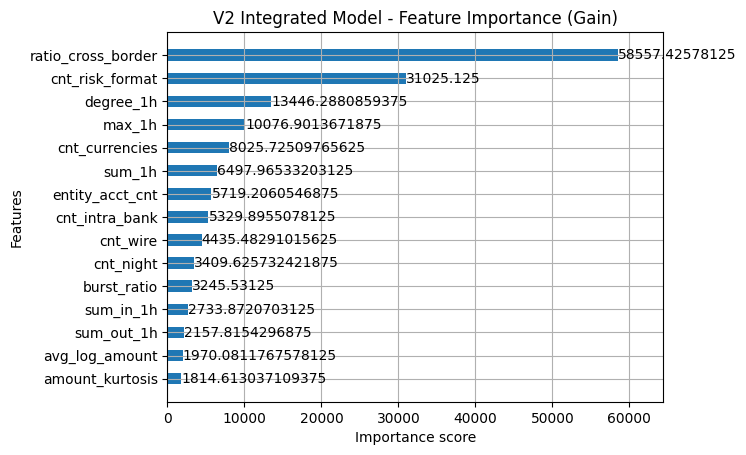

In [2]:
# -------------------------------------------------------------------------
# 6. [STEP 3] 모델 튜닝 (오탐 방어 및 일반화 모드)
# -------------------------------------------------------------------------
# V1 튜닝 로직 계승: 가중치를 낮추고 트리를 보수적으로 설정
params_tuned = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 5,            # 트리 깊이 축소 (과적합 방지)
    'learning_rate': 0.05,      # 학습 속도 최적화
    'scale_pos_weight': 100,    # 424 -> 100 하향 (오탐 감소 핵심)
    'min_child_weight': 10,     # 작은 노드 생성 억제
    'subsample': 0.8,           # 데이터 샘플링 활용
    'tree_method': 'hist',
    'random_state': 42
}

print("\n🏋️ [Step 3] 튜닝된 파라미터로 고도화 모델 재학습 시작...")
model_tuned = xgb.train(
    params_tuned,
    dtrain,
    num_boost_round=1000,       # 학습률이 낮으므로 라운드 수 증가
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=20,
    verbose_eval=100
)

# -------------------------------------------------------------------------
# 7. [STEP 4] 튜닝 모델 최종 평가 (전체/일별 Top-K)
# -------------------------------------------------------------------------
print("\n🎯 [Step 4] 튜닝 결과 최종 평가 (Threshold 0.7 적용)")
preds_tuned = model_tuned.predict(dtest)

# 확실한 경우(0.7 초과)만 1로 분류 (V1 튜닝 로직 동일)
threshold = 0.7
y_pred_tuned = [1 if p > threshold else 0 for p in preds_tuned]
y_true = dtest.get_label()

print("-" * 60)
print(classification_report(y_true, y_pred_tuned))
current_auprc = average_precision_score(y_true, preds_tuned)
print(f"✅ Final Average Precision (AUPRC): {current_auprc:.4f}")

# 고도화 모델의 Top-K 분석 수행
analyze_top_k(test_df, preds_tuned, y_true)

# -------------------------------------------------------------------------
# 8. 피처 중요도 분석 (어떤 고도화 지표가 기여했나?)
# -------------------------------------------------------------------------
print("\n🔥 V2 고도화 모델 피처 중요도 (Top 15 - Gain 기준):")
importance = model_tuned.get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

for i, (f, s) in enumerate(sorted_importance[:15]):
    # 신규 추가된 피처인지 확인 표시
    is_new = "✨ [NEW]" if f in ["cnt_cash", "cnt_wire", "cnt_cheque", "cnt_inter_bank", 
                                 "median_amount", "amount_skewness", "amount_kurtosis", "cluster_risk_score"] else ""
    print(f"{i+1:2d}. {f:<25} : {s:>12.2f} {is_new}")

# 중요도 시괄화
plt.figure(figsize=(12, 8))
xgb.plot_importance(model_tuned, max_num_features=15, importance_type='gain', height=0.5)
plt.title("V2 Integrated Model - Feature Importance (Gain)")
plt.show()


🔥 V2 고도화 모델 피처 중요도 (Top 30 - Gain 기준):
 1. ratio_cross_border        :     58557.43 
 2. cnt_risk_format           :     31025.12 
 3. degree_1h                 :     13446.29 
 4. max_1h                    :     10076.90 
 5. cnt_currencies            :      8025.73 
 6. sum_1h                    :      6497.97 
 7. entity_acct_cnt           :      5719.21 
 8. cnt_intra_bank            :      5329.90 
 9. cnt_wire                  :      4435.48 ✨ [NEW]
10. cnt_night                 :      3409.63 
11. burst_ratio               :      3245.53 
12. sum_in_1h                 :      2733.87 
13. sum_out_1h                :      2157.82 
14. avg_log_amount            :      1970.08 
15. amount_kurtosis           :      1814.61 ✨ [NEW]
16. cnt_1h                    :      1746.26 
17. cluster_risk_score        :      1671.92 ✨ [NEW]
18. median_amount             :      1455.91 ✨ [NEW]
19. cnt_weekend               :      1333.60 
20. cnt_inter_bank            :      1275.07 ✨ [NEW]
21. t

<Figure size 1200x800 with 0 Axes>

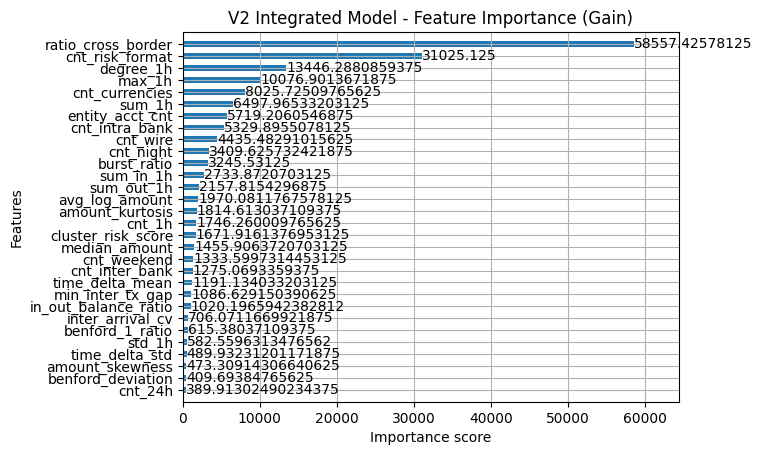

In [4]:
# -------------------------------------------------------------------------
# 8. 피처 중요도 분석 (어떤 고도화 지표가 기여했나?)
# -------------------------------------------------------------------------
print("\n🔥 V2 고도화 모델 피처 중요도 (Top 30 - Gain 기준):")
importance = model_tuned.get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

for i, (f, s) in enumerate(sorted_importance[:30]):
    # 신규 추가된 피처인지 확인 표시
    is_new = "✨ [NEW]" if f in ["cnt_cash", "cnt_wire", "cnt_cheque", "cnt_inter_bank", 
                                 "median_amount", "amount_skewness", "amount_kurtosis", "cluster_risk_score"] else ""
    print(f"{i+1:2d}. {f:<25} : {s:>12.2f} {is_new}")

# 중요도 시괄화
plt.figure(figsize=(12, 8))
xgb.plot_importance(model_tuned, max_num_features=30, importance_type='gain', height=0.5)
plt.title("V2 Integrated Model - Feature Importance (Gain)")
plt.show()

In [1]:
import polars as pl

# 1. V2 통합 데이터셋 로드
file_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
df = pl.read_parquet(file_path)

# 2. 코드에 정의된 제외 컬럼 리스트
exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode"]

# 3. 실제 학습에 사용된 피처 리스트 생성
features = [col for col in df.columns if col not in exclude_cols]

# 4. 결과 출력
print(f"📊 [피처 점검 결과]")
print(f"✅ 전체 컬럼 수: {len(df.columns)}개")
print(f"✅ 제외된 컬럼 수: {len(exclude_cols)}개")
print(f"🚀 실제 학습에 사용된 피처 수: {len(features)}개")
print("-" * 50)
print(f"📋 피처 목록 ({len(features)}개):")
print(features)

📊 [피처 점검 결과]
✅ 전체 컬럼 수: 43개
✅ 제외된 컬럼 수: 5개
🚀 실제 학습에 사용된 피처 수: 38개
--------------------------------------------------
📋 피처 목록 (38개):
['cnt_1h', 'time_delta_mean', 'time_delta_std', 'min_inter_tx_gap', 'cnt_night', 'cnt_weekend', 'sum_1h', 'max_1h', 'std_1h', 'sum_out_1h', 'sum_in_1h', 'cnt_small_tx', 'cnt_risk_country', 'ratio_cross_border', 'degree_1h', 'entity_acct_cnt', 'cnt_risk_format', 'benford_1_ratio', 'avg_log_amount', 'sum_24h', 'cnt_24h', 'avg_7d', 'burst_ratio', 'in_out_balance_ratio', 'inter_arrival_cv', 'benford_deviation', 'ratio_risk_country', 'cnt_cash', 'cnt_wire', 'cnt_cheque', 'cnt_credit', 'cnt_currencies', 'cnt_inter_bank', 'cnt_intra_bank', 'median_amount', 'amount_skewness', 'amount_kurtosis', 'cluster_risk_score']


In [1]:
import polars as pl
import xgboost as xgb
from sklearn.metrics import classification_report, average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import warnings

warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# 1. 고도화된 V2 통합 파일 로드
# -------------------------------------------------------------------------
file_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
print("📂 V2 통합 데이터셋 로딩 중...")
df = pl.read_parquet(file_path)

# -------------------------------------------------------------------------
# 2. 시간 순서대로 6:2:2 분할 (사용자님 로직 준수)
# -------------------------------------------------------------------------
print("✂️ 시간 기반 데이터 분할 중 (Train: 60%, Val: 20%, Test: 20%)...")
df = df.sort("time_group")
total_len = len(df)
train_end = int(total_len * 0.6)
val_end = int(total_len * 0.8)

train_df = df.slice(0, train_end)
val_df = df.slice(train_end, val_end - train_end)
test_df = df.slice(val_end, total_len - val_end)

# 🚨 [중요] 누수 방지: Timestamp 및 timestamp 컬럼을 학습 피처에서 원천 차단
exclude_cols = [
    "account_id", "time_group", "is_laundering", "mode_format", "currency_mode",
    "Timestamp", "timestamp", "is_fraud_node_train" # 누수 방지 리스트 추가
]
features = [col for col in df.columns if col not in exclude_cols]
target = "is_laundering"

print(f"✅ 학습 피처 수: {len(features)}개 (시간 치트키 제거 완료)")

# 3. XGBoost용 DMatrix 변환
print("🚀 DMatrix 변환 중...")
dtrain = xgb.DMatrix(train_df.select(features).to_pandas(), label=train_df[target].to_pandas())
dval = xgb.DMatrix(val_df.select(features).to_pandas(), label=val_df[target].to_pandas())
dtest = xgb.DMatrix(test_df.select(features).to_pandas(), label=test_df[target].to_pandas())

# -------------------------------------------------------------------------
# 4. 분석 함수 (전체/일별 Top-K 포함)
# -------------------------------------------------------------------------
def analyze_model(model, dmat, test_df_pl, name, threshold=0.7):
    probs = model.predict(dmat)
    y_true = dmat.get_label()
    y_pred = (probs > threshold).astype(int)
    
    print(f"\n" + "="*60)
    print(f"🏆 [{name}] 종합 평가 결과 (Threshold: {threshold})")
    print("="*60)
    print(classification_report(y_true, y_pred, digits=4))
    print(f"📌 Final AUPRC: {average_precision_score(y_true, probs):.4f}")
    
    # Top-K 분석
    eval_df = pd.DataFrame({
        'date': test_df_pl['time_group'].dt.date().to_pandas(), 
        'prob': probs, 
        'actual': y_true
    })
    
    print(f"\n[전체 Top-K 탐지 성능]")
    sorted_df = eval_df.sort_values(by='prob', ascending=False).reset_index(drop=True)
    for k in [100, 500, 1000]:
        hits = sorted_df.head(k)['actual'].sum()
        print(f"Top {k:<5} | 실제 범인: {int(hits):<6} | 정밀도: {hits/k:.2%}")

    print(f"\n[일자별 Top-100 탐지 성능]")
    daily_results = []
    for d in sorted(eval_df['date'].unique()):
        day_data = eval_df[eval_df['date'] == d]
        day_hits = day_data.sort_values(by='prob', ascending=False).head(100)['actual'].sum()
        daily_results.append({'Date': d, 'Hits@100': int(day_hits)})
    print(pd.DataFrame(daily_results).to_string(index=False))

# -------------------------------------------------------------------------
# 5. [Step 1] 기본 모델 학습 (Basic - 가중치 424)
# -------------------------------------------------------------------------
params_basic = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 6, 'learning_rate': 0.1, 'scale_pos_weight': 424,
    'tree_method': 'hist', 'random_state': 42
}

print("\n🏋️ [Step 1] V2 Clean Basic 학습 시작...")
model_basic = xgb.train(
    params_basic, dtrain, num_boost_round=500,
    evals=[(dval, 'val')], early_stopping_rounds=10, verbose_eval=False
)
analyze_model(model_basic, dtest, test_df, "V2 Clean Basic", threshold=0.5)

# -------------------------------------------------------------------------
# 6. [Step 2] 튜닝 모델 학습 (Tuned - 가중치 100)
# -------------------------------------------------------------------------
params_tuned = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100,
    'min_child_weight': 10, 'subsample': 0.8, 'tree_method': 'hist', 'random_state': 42
}

print("\n🏋️ [Step 2] V2 Clean Tuned 학습 시작...")
model_tuned = xgb.train(
    params_tuned, dtrain, num_boost_round=1000,
    evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False
)
analyze_model(model_tuned, dtest, test_df, "V2 Clean Tuned", threshold=0.7)

# 메모리 정리
del train_df, val_df; gc.collect()

📂 V2 통합 데이터셋 로딩 중...
✂️ 시간 기반 데이터 분할 중 (Train: 60%, Val: 20%, Test: 20%)...
✅ 학습 피처 수: 38개 (시간 치트키 제거 완료)
🚀 DMatrix 변환 중...

🏋️ [Step 1] V2 Clean Basic 학습 시작...

🏆 [V2 Clean Basic] 종합 평가 결과 (Threshold: 0.5)
              precision    recall  f1-score   support

         0.0     0.9998    0.9501    0.9743   5730722
         1.0     0.0630    0.9377    0.1182     20539

    accuracy                         0.9500   5751261
   macro avg     0.5314    0.9439    0.5462   5751261
weighted avg     0.9964    0.9500    0.9712   5751261

📌 Final AUPRC: 0.5203

[전체 Top-K 탐지 성능]
Top 100   | 실제 범인: 100    | 정밀도: 100.00%
Top 500   | 실제 범인: 496    | 정밀도: 99.20%
Top 1000  | 실제 범인: 987    | 정밀도: 98.70%

[일자별 Top-100 탐지 성능]
      Date  Hits@100
2022-09-14       100
2022-09-15       100
2022-09-16        92
2022-09-17       100
2022-09-18       100
2022-09-19       100
2022-09-20       100
2022-09-21       100
2022-09-22       100
2022-09-23       100
2022-09-24       100
2022-09-25       100
2022-09-26 

76